# (13) tbptt: (T, beta) = (128[32], 256.0)

project = ```iP-VAE```, host = ```chewie```, device = ```cuda:1```

**Motivation**: <br>

This uses the ```tr.cfg.tbptt_accumulate=True``` option (more standard gradient accumulation)

In [20]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

## Trainer

In [3]:
cfg_vae, cfg_tr = default_configs('vH16', 'grad|lin')

cfg_vae['seq_len'] = 128
cfg_vae['tbptt_steps'] = 32
cfg_vae['n_iters_inner'] = 1

cfg_vae['track_stats'] = True

cfg_tr['kl_beta'] = 256.0
cfg_tr['tbptt_accumulate'] = True

# cfg_tr['batch_size'] = 100
# cfg_tr['epochs'] = 200

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  132.3 K   |
|     ———     |    ———     |
|    layer    |  132.3 K   |
+-------------+------------+

vH16_t-128[§32]_z-[512]_<grad|lin>
b200-ep300-lr(0.002)_beta(256:0.1)_temp(0.05:0.5)_gr(200)_(2025_02_13,10:20)

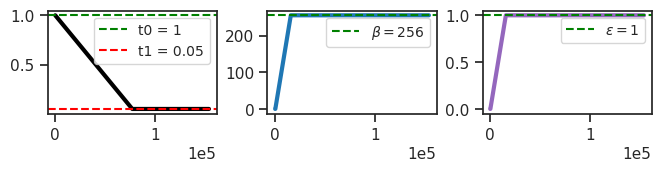

In [4]:
mod = IPVAE(ConfigPoisVAE(**cfg_vae))
tr = Trainer(mod, ConfigTrain(**cfg_tr), device=device)

mod.print()
print(f"{mod.cfg.name()}\n{tr.cfg.name()}_({mod.timestamp})\n")
tr.show_schedules()

In [5]:
print(tr.n_iters, tr.cfg.tbptt_accumulate)

154500 True

In [6]:
print(tr.model.layer)

PoissonLayer(input_dim=256, latent_dim=512, temperature=1, beta_inner=1, eps=1)

In [7]:
tr.model.layer.log_bias.shape, tr.model.layer.log_lr.exp()

(torch.Size([1, 512]), tensor([1.], device='cuda:1', grad_fn=<ExpBackward0>))

In [8]:
cm = f"accumu={tr.cfg.tbptt_accumulate}"
tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

# tr.train()

epoch # 300, avg loss: 221.517060: 100%|██| 300/300 [16:00:23<00:00, 192.08s/it]


In [21]:
print(tr.model.layer.n_exp)

tensor([ 35,  37,  40,  43,  46,  49,  53,  56,  60,  63,  67,  70,  74,  77,
         80,  84,  87,  90,  92,  95,  97, 100, 102, 104, 106, 108, 109, 111,
        112, 113, 114, 115, 116, 117, 117, 118, 118, 119, 119, 120, 120, 120,
        120, 121, 121, 121, 121, 121, 121, 121, 122, 122, 122, 122, 122, 122,
        122, 122, 122, 122, 122, 122, 122, 122, 122, 122, 122, 121, 121, 121,
        121, 121, 121, 121, 121, 121, 121, 121, 121, 121, 121, 121, 121, 121,
        121, 121, 121, 121, 121, 121, 121, 121, 121, 121, 121, 121, 121, 121,
        120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120,
        120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120,
        120, 120], device='cuda:1', dtype=torch.int32)

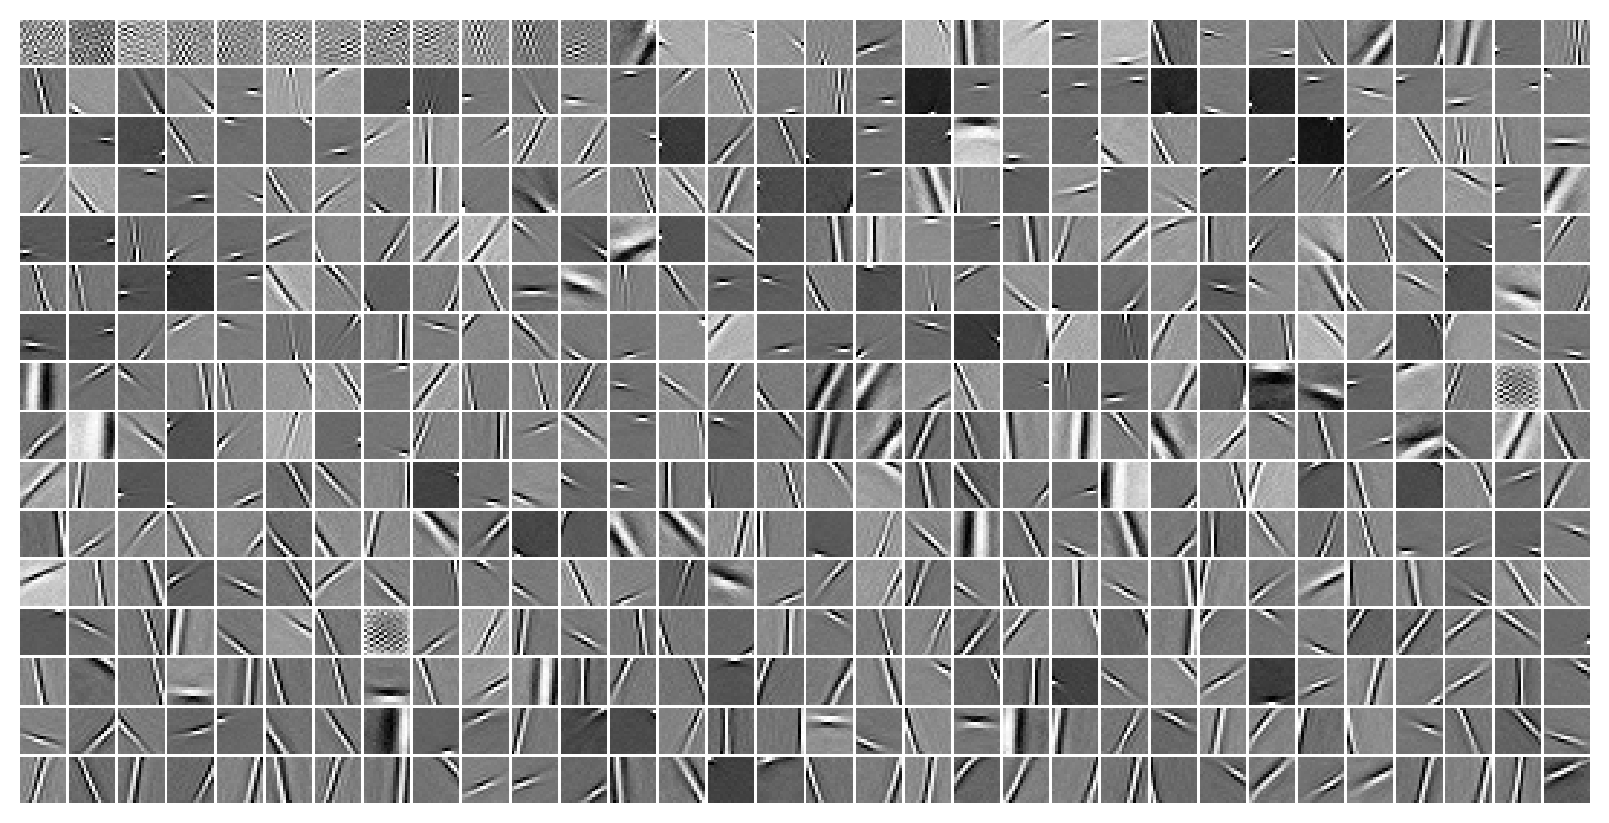

In [22]:
u0 = tonp(tr.model.layer.u_init.squeeze())
tr.model.show(order=np.argsort(u0));

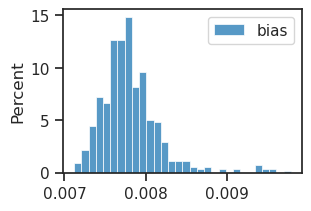

In [11]:
fig, ax = create_figure()

sns.histplot(tonp(tr.model.layer.log_bias.squeeze().exp()), label='bias', stat='percent',  ax=ax)
ax.legend()
plt.show()

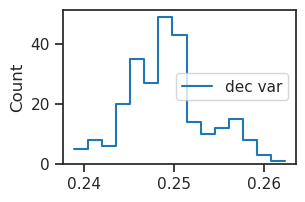

In [12]:
log_scale = tonp(tr.model.layer.log_scale.squeeze())
histplot(np.exp(log_scale) ** 2, label='dec var')
plt.legend()
plt.show()

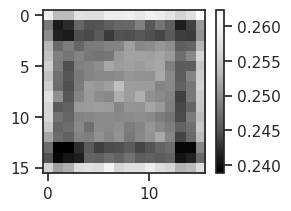

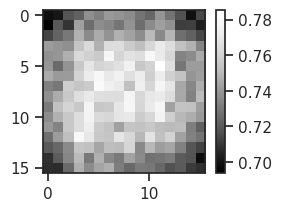

In [13]:
var = np.exp(log_scale) ** 2
var = var.reshape(16, 16)

var_data = tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze()

fig, ax =  create_figure()
imshow(var, cmap='Greys_r')
plt.colorbar()
plt.show()

fig, ax =  create_figure()
imshow(var_data, cmap='Greys_r')
plt.colorbar()
plt.show()

100%|███████████████████████████████████| 3/3 [03:14<00:00, 64.89s/it]


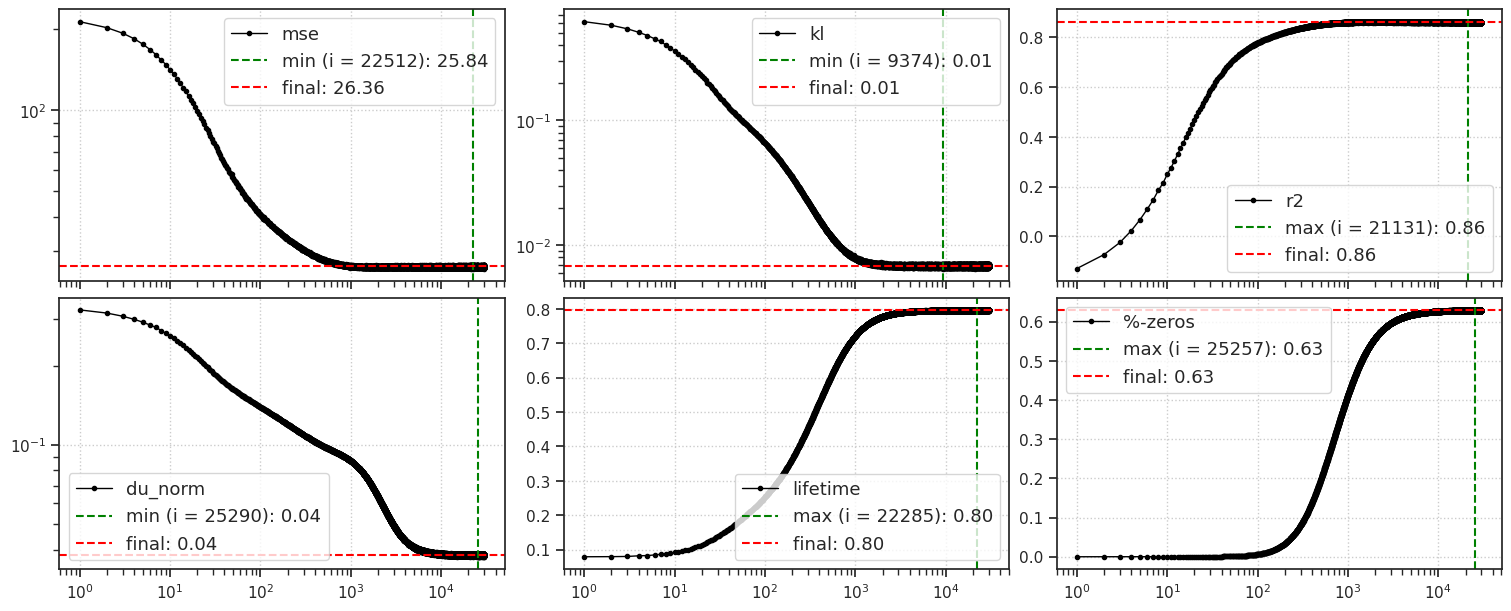

CPU times: user 3min 53s, sys: 14.3 s, total: 4min 7s
Wall time: 4min 7s


In [23]:
%%time

kws = dict(
    seq_total=30000,
    seq_batch_sz=3000,
    n_data_batches=3,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

## output

In [24]:
output = tr.model.xtract_ftr(
    feeder=tr.get_feeder(),
    seq=range(1000),
    return_extras=True,
).stack()

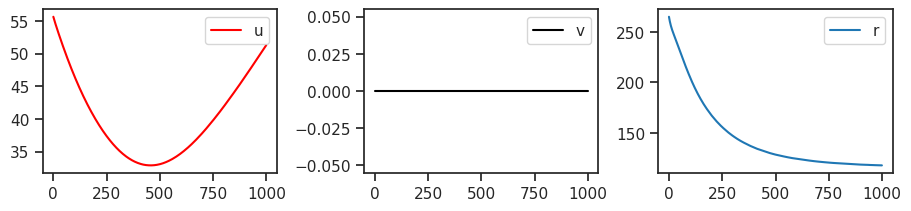

In [25]:
u_norm = tonp(torch.linalg.norm(output['u'], axis=-1).mean(0))
v_norm = tonp(torch.linalg.norm(output['v'], axis=-1).mean(0))
r_norm = tonp(torch.linalg.norm(torch.exp(output['u']), axis=-1).mean(0))

fig, axes = create_figure(1, 3)
axes[0].plot(u_norm, label='u', color='r')
axes[1].plot(v_norm, label='v', color='k')
axes[2].plot(r_norm, label='r')

add_legend(axes)
plt.show()

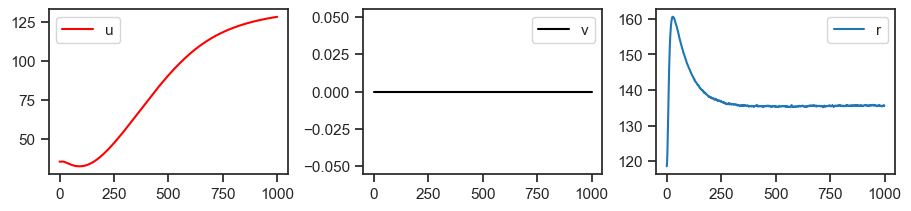

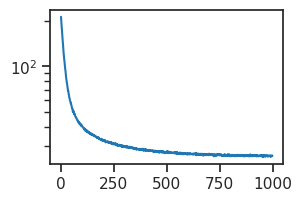

tensor([25.9120, 25.9806, 25.9344, 26.1456, 26.0026], device='cuda:1')

In [26]:
feeder = tr.get_feeder()

locs = torch.stack([
    p.loc for p in
    output['conditional'].values()
], dim=1)
mse = (locs - feeder[0].unsqueeze(1)).pow(2).sum(-1)
plot(mse.mean(0))
plt.yscale('log')
plt.show()

mse.mean(0)[-5:]

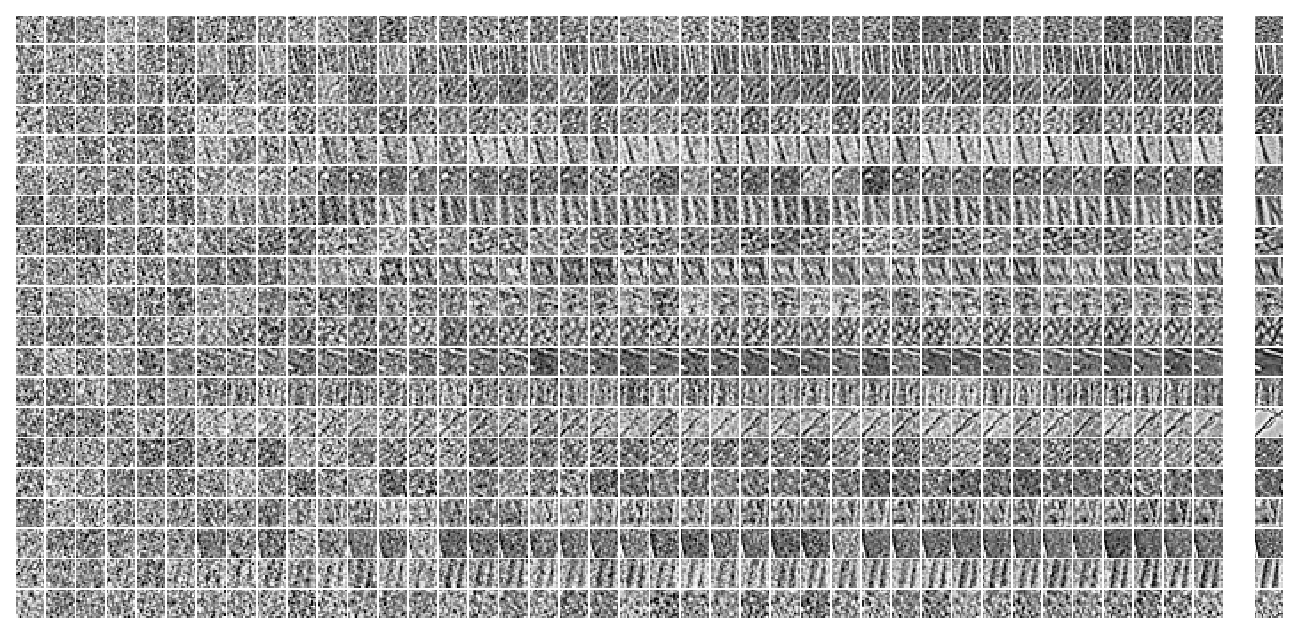

In [27]:
num = 20
n_timepoints = 40

x2p = tonp(locs)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)

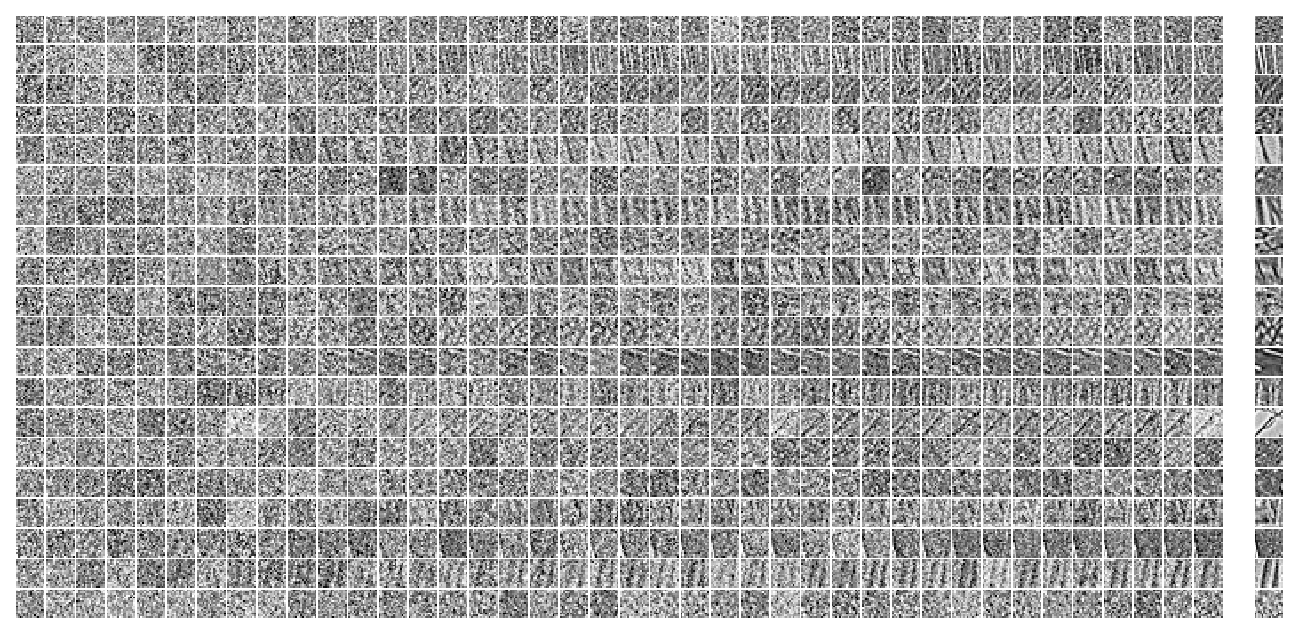

In [28]:
x2p = tonp(output['recon'])[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)

In [30]:
tr.time_keys

{'first': '0', 'last': '127', 'avg': 'avg'}

In [29]:
data, loss, etc = tr.forward('vld')
list(loss)

['kl', 'kl_diag', 'recon', 'nelbo']

In [31]:
from main.train import _prep

In [32]:
print(_prep(loss['kl'].mean(0)))

{
    '0': 0.6154973,
    '1': 0.5754478,
    '2': 0.5394241,
    '3': 0.50573325,
    '4': 0.47599205,
    '5': 0.44845414,
    '6': 0.42280412,
    '7': 0.3993913,
    '8': 0.37801218,
    '9': 0.35841337,
    '10': 0.33976945,
    '11': 0.32275078,
    '12': 0.30723366,
    '13': 0.2923784,
    '14': 0.2789763,
    '15': 0.26657724,
    '16': 0.25485402,
    '17': 0.24379775,
    '18': 0.23370539,
    '19': 0.22461598,
    '20': 0.2159215,
    '21': 0.20775235,
    '22': 0.20004636,
    '23': 0.19330814,
    '24': 0.18676704,
    '25': 0.18064621,
    '26': 0.17490008,
    '27': 0.1696986,
    '28': 0.1646811,
    '29': 0.15990342,
    '30': 0.15564695,
    '31': 0.15163857,
    '32': 0.14780004,
    '33': 0.14436525,
    '34': 0.14079814,
    '35': 0.1376639,
    '36': 0.13478822,
    '37': 0.1319261,
    '38': 0.12912335,
    '39': 0.12672825,
    '40': 0.12428519,
    '41': 0.12206528,
    '42': 0.12007001,
    '43': 0.11793466,
    '44': 0.11598391,
    '45': 0.1141094,
    '46': 0.11242022,
    '47': 0.11065811,
    '48': 0.10904158,
    '49': 0.107515685,
    '50': 0.10594481,
    '51': 0.1045904,
    '52': 0.10313838,
    '53': 0.10177082,
    '54': 0.10054267,
    '55': 0.0993046,
    '56': 0.09801918,
    '57': 0.09703124,
    '58': 0.09581505,
    '59': 0.094756074,
    '60': 0.09370624,
    '61': 0.09261558,
    '62': 0.09166478,
    '63': 0.090655036,
    '64': 0.08970579,
    '65': 0.08874594,
    '66': 0.08781852,
    '67': 0.08704965,
    '68': 0.086086154,
    '69': 0.08528622,
    '70': 0.08444522,
    '71': 0.08367748,
    '72': 0.08278569,
    '73': 0.082086906,
    '74': 0.08138601,
    '75': 0.08056131,
    '76': 0.07984929,
    '77': 0.07914974,
    '78': 0.07840142,
    '79': 0.07778114,
    '80': 0.07702248,
    '81': 0.076371916,
    '82': 0.075694434,
    '83': 0.075029574,
    '84': 0.07441962,
    '85': 0.0738134,
    '86': 0.073134914,
    '87': 0.072578214,
    '88': 0.071973205,
    '89': 0.07139938,
    '90': 0.07082967,
    '91': 0.07020437,
    '92': 0.06961964,
    '93': 0.069115184,
    '94': 0.06850976,
    '95': 0.068019606,
    '96': 0.06748541,
    '97': 0.066989,
    '98': 0.06644052,
    '99': 0.06590573,
    '100': 0.0654211,
    '101': 0.064943016,
    '102': 0.064373426,
    '103': 0.06393316,
    '104': 0.06345479,
    '105': 0.06295319,
    '106': 0.06248936,
    '107': 0.062028065,
    '108': 0.061610118,
    '109': 0.061104015,
    '110': 0.060681976,
    '111': 0.060247082,
    '112': 0.059740476,
    '113': 0.059338607,
    '114': 0.058915,
    '115': 0.058516517,
    '116': 0.058041476,
    '117': 0.057640366,
    '118': 0.057233132,
    '119': 0.056823637,
    '120': 0.056392554,
    '121': 0.056042906,
    '122': 0.0556951,
    '123': 0.05528845,
    '124': 0.054906696,
    '125': 0.05448785,
    '126': 0.054152727,
    '127': 0.05376574,
    'avg': 0.13813409450813197
}

In [33]:
print(_prep(loss['recon'].mean(0)))

{
    '0': 482.40363,
    '1': 461.7396,
    '2': 442.3913,
    '3': 424.188,
    '4': 407.81003,
    '5': 391.90817,
    '6': 377.5285,
    '7': 364.14288,
    '8': 351.458,
    '9': 339.73938,
    '10': 328.48138,
    '11': 318.09692,
    '12': 308.72897,
    '13': 299.7088,
    '14': 291.24603,
    '15': 283.32956,
    '16': 275.8756,
    '17': 269.00723,
    '18': 262.1881,
    '19': 256.01346,
    '20': 250.44919,
    '21': 245.09956,
    '22': 239.80452,
    '23': 235.04422,
    '24': 230.51842,
    '25': 226.15878,
    '26': 222.18932,
    '27': 218.34143,
    '28': 214.64606,
    '29': 211.28525,
    '30': 208.12154,
    '31': 205.03766,
    '32': 202.08669,
    '33': 199.3371,
    '34': 196.8933,
    '35': 194.34003,
    '36': 192.00984,
    '37': 189.83214,
    '38': 187.70837,
    '39': 185.60641,
    '40': 183.75415,
    '41': 181.81747,
    '42': 180.03067,
    '43': 178.42363,
    '44': 176.84201,
    '45': 175.38408,
    '46': 173.93199,
    '47': 172.4069,
    '48': 171.14354,
    '49': 169.70215,
    '50': 168.6651,
    '51': 167.57016,
    '52': 166.30223,
    '53': 165.23514,
    '54': 164.25871,
    '55': 163.21513,
    '56': 162.2599,
    '57': 161.30147,
    '58': 160.44926,
    '59': 159.50807,
    '60': 158.75998,
    '61': 157.89513,
    '62': 157.15404,
    '63': 156.28566,
    '64': 155.7022,
    '65': 154.90814,
    '66': 154.17834,
    '67': 153.5321,
    '68': 152.91025,
    '69': 152.31981,
    '70': 151.74548,
    '71': 151.10753,
    '72': 150.5074,
    '73': 150.00827,
    '74': 149.4929,
    '75': 148.91028,
    '76': 148.4182,
    '77': 147.88185,
    '78': 147.36995,
    '79': 147.0068,
    '80': 146.49269,
    '81': 146.01889,
    '82': 145.60054,
    '83': 145.22623,
    '84': 144.7128,
    '85': 144.2674,
    '86': 143.91849,
    '87': 143.60254,
    '88': 143.24396,
    '89': 142.80112,
    '90': 142.51324,
    '91': 142.10236,
    '92': 141.80148,
    '93': 141.4156,
    '94': 141.07639,
    '95': 140.84169,
    '96': 140.61617,
    '97': 140.14429,
    '98': 139.91733,
    '99': 139.60793,
    '100': 139.2999,
    '101': 139.02039,
    '102': 138.76787,
    '103': 138.47273,
    '104': 138.1655,
    '105': 137.85904,
    '106': 137.71156,
    '107': 137.46152,
    '108': 137.09233,
    '109': 136.91647,
    '110': 136.62538,
    '111': 136.49538,
    '112': 136.17587,
    '113': 136.00816,
    '114': 135.70937,
    '115': 135.52338,
    '116': 135.30208,
    '117': 135.17804,
    '118': 134.84706,
    '119': 134.64497,
    '120': 134.4082,
    '121': 134.24426,
    '122': 134.10547,
    '123': 133.9037,
    '124': 133.61145,
    '125': 133.47499,
    '126': 133.22617,
    '127': 133.07875,
    'avg': 189.85970759391785
}

In [34]:
print(_prep(loss['nelbo'].mean(0)))

{
    '0': 483.01758,
    '1': 462.31396,
    '2': 442.9286,
    '3': 424.69373,
    '4': 408.28418,
    '5': 392.35892,
    '6': 377.95184,
    '7': 364.54315,
    '8': 351.83658,
    '9': 340.09662,
    '10': 328.82288,
    '11': 318.41898,
    '12': 309.03738,
    '13': 300.00113,
    '14': 291.52615,
    '15': 283.5979,
    '16': 276.13013,
    '17': 269.2513,
    '18': 262.423,
    '19': 256.23944,
    '20': 250.667,
    '21': 245.30817,
    '22': 240.0038,
    '23': 235.23738,
    '24': 230.70462,
    '25': 226.3401,
    '26': 222.36444,
    '27': 218.51152,
    '28': 214.81119,
    '29': 211.44429,
    '30': 208.27646,
    '31': 205.18994,
    '32': 202.23479,
    '33': 199.48132,
    '34': 197.0316,
    '35': 194.47699,
    '36': 192.14491,
    '37': 189.9642,
    '38': 187.8383,
    '39': 185.73453,
    '40': 183.8785,
    '41': 181.94073,
    '42': 180.14954,
    '43': 178.54213,
    '44': 176.95795,
    '45': 175.49843,
    '46': 174.04475,
    '47': 172.5185,
    '48': 171.25232,
    '49': 169.81047,
    '50': 168.77179,
    '51': 167.67464,
    '52': 166.40616,
    '53': 165.3368,
    '54': 164.35887,
    '55': 163.31407,
    '56': 162.35838,
    '57': 161.39822,
    '58': 160.54445,
    '59': 159.60213,
    '60': 158.85374,
    '61': 157.98749,
    '62': 157.24596,
    '63': 156.37563,
    '64': 155.79292,
    '65': 154.99683,
    '66': 154.2658,
    '67': 153.6189,
    '68': 152.99687,
    '69': 152.40584,
    '70': 151.83017,
    '71': 151.19234,
    '72': 150.59029,
    '73': 150.09015,
    '74': 149.57437,
    '75': 148.99092,
    '76': 148.49812,
    '77': 147.96094,
    '78': 147.4488,
    '79': 147.08432,
    '80': 146.56963,
    '81': 146.09474,
    '82': 145.67685,
    '83': 145.30238,
    '84': 144.78708,
    '85': 144.34222,
    '86': 143.99162,
    '87': 143.67497,
    '88': 143.31555,
    '89': 142.87334,
    '90': 142.58372,
    '91': 142.17221,
    '92': 141.8718,
    '93': 141.48453,
    '94': 141.14497,
    '95': 140.90913,
    '96': 140.68405,
    '97': 140.21164,
    '98': 139.98415,
    '99': 139.67357,
    '100': 139.36592,
    '101': 139.08546,
    '102': 138.83202,
    '103': 138.53613,
    '104': 138.22952,
    '105': 137.92252,
    '106': 137.77423,
    '107': 137.52342,
    '108': 137.15446,
    '109': 136.97768,
    '110': 136.68553,
    '111': 136.55582,
    '112': 136.23552,
    '113': 136.06807,
    '114': 135.7677,
    '115': 135.58292,
    '116': 135.36015,
    '117': 135.23508,
    '118': 134.90411,
    '119': 134.70125,
    '120': 134.46498,
    '121': 134.30075,
    '122': 134.16019,
    '123': 133.95906,
    '124': 133.66692,
    '125': 133.52959,
    '126': 133.28009,
    '127': 133.13258,
    'avg': 189.99795353412628
}